✅ Daten erfolgreich geladen: Stand Epoche 7606


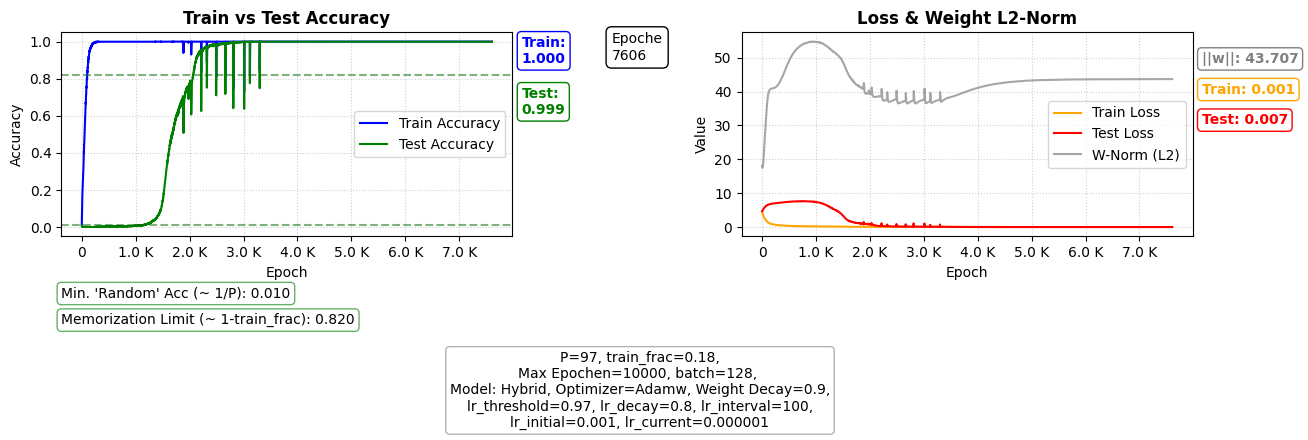

In [44]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# -----------------------------------------------------------------------------
# Pfadkonfiguration & Daten-Import
# -----------------------------------------------------------------------------
# Pfad zum spezifischen Experiment-Run (automatisch generiert vom Training-Skript) 
# Pfad mit den entsprechenden richtigen Name anpassen

#RUN_DIR = f"./runs/grok_P97_hybrid_ohne_LR_Scheduler_20260215_183143" # ohne Scheduler
RUN_DIR = f"./runs/grok_P97_hybrid_mit_LR_Scheduler_20260215_172640" # mit Scheduler

CSV_PATH = os.path.join(RUN_DIR, "history.csv")
SETTINGS_PATH = os.path.join(os.path.dirname(CSV_PATH), "training_settings.txt")

def safe_float(value, decimals=6):
    """Wandelt Wert in Float um, falls möglich, sonst bleibt er 'N/A'."""
    try:
        return f"{float(value):.{decimals}f}"
    except (ValueError, TypeError):
        return "N/A"

# Laden der Experiment-Konfiguration
def load_training_settings(path):
    """
    Extrahiert Hyperparameter aus der generierten Metadaten-Datei.
    Erzeugt ein Dictionary für die dynamische Beschriftung der Plots.
    """
    settings = {}
    if os.path.exists(path):
        with open(path, "r", encoding="utf-8") as f:
            for line in f:
                line = line.strip()
                if not line or line.startswith("="):
                    continue
                if ":" in line:
                    key, value = line.split(":", 1)
                    settings[key.strip()] = value.strip()
    return settings

# Laden der Experiment-Konfiguration
loaded_training_settings = load_training_settings(SETTINGS_PATH)

# Extraktion der Parameter für die mathematische Einordnung
P = int(loaded_training_settings.get("P", "N/A"))

LR = loaded_training_settings.get("LR", "N/A")                                               
BATCH_SIZE = loaded_training_settings.get("BATCH_SIZE", "N/A")
MODEL_TYPE = loaded_training_settings.get("MODEL_TYPE", "N/A") 
OPTIMIZER = loaded_training_settings.get("Optimizer Name", "N/A")
WEIGHT_DECAY = loaded_training_settings.get("WEIGHT_DECAY", "N/A")
EPOCHS = loaded_training_settings.get("TOTAL_TARGET_EPOCHS", "N/A")
train_frac = loaded_training_settings.get("train_frac", "N/A")
USE_SCHEDULER = loaded_training_settings.get("USE_SCHEDULER", "N/A")
SCHEDULER_THRESHOLD = loaded_training_settings.get("SCHEDULER_THRESHOLD", "N/A")
SCHEDULER_DECAY_RATE = loaded_training_settings.get("SCHEDULER_DECAY_RATE", "N/A")
SCHEDULER_PATIENCE = loaded_training_settings.get("SCHEDULER_PATIENCE", "N/A") 

# Hier nutzen wir die sichere Umwandlung für die aktuelle LR
LR_CURRENT_RAW = loaded_training_settings.get("learning_rate", "N/A")
LR_CURRENT = safe_float(LR_CURRENT_RAW)

# Theoretische Benchmarks für die Evaluation:
# 'Random Guess' ist die Basis-Accuracy bei zufälliger Vorhersage (1/P).
random_guess = 1/P
random_guess_test = 1 - float(train_frac)

# -----------------------------------------------------------------------------
# Datenaufbereitung (Pandas)
# -----------------------------------------------------------------------------
cols = ["epoch", "train_acc", "test_acc", "train_loss", "test_loss", "w_norm"]

try:
    # Laden der Historie. usecols stellt sicher, dass exakt 6 Spalten eingelesen werden.
    history_df = pd.read_csv(CSV_PATH, names=cols, header=0, usecols=range(len(cols)))
    
    # Extraktion der finalen Metriken für die Annotationen im Plot
    last_row        = history_df.iloc[-1] 
    last_epoch      = int(last_row["epoch"])
    last_train_acc  = last_row["train_acc"]
    last_test_acc   = last_row["test_acc"]
    last_train_loss = last_row["train_loss"]
    last_test_loss  = last_row["test_loss"]
    last_w_norm     = last_row["w_norm"]

    print(f"✅ Daten erfolgreich geladen: Stand Epoche {last_epoch}")

except Exception as e:
    print(f"❌ Fehler beim Laden der CSV: {e}")

# -----------------------------------------------------------------------------
# Visualisierung: Accuracy & Loss-Dynamik
# -----------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(15,5))

# Formatierung der X-Achse (z.B. 15000 -> 15.0 K) für bessere Lesbarkeit bei Grokking-Skalen
def kfmt(x, pos):
    if x >= 1000:
        return f"{round(x/1000,1)} K"
    return f"{int(x)}"

# --- Plot 1: Accuracy (Train vs. Test) ---
# Hier wird der "Aha-Moment" (Grokking) sichtbar, wenn Test-Acc schlagartig steigt.
axes[0].plot(history_df["epoch"], history_df["train_acc"], label="Train Accuracy", color="blue")
axes[0].plot(history_df["epoch"], history_df["test_acc"], label="Test Accuracy", color="green")
axes[0].axhline(y=random_guess, color="darkgreen", linestyle="--", alpha=0.5)
axes[0].axhline(y=random_guess_test, color="darkgreen", linestyle="--", alpha=0.5)

axes[0].xaxis.set_major_formatter(FuncFormatter(kfmt))
axes[0].set_title("Train vs Test Accuracy", color="black", weight="bold")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].grid(True, linestyle=':', alpha=0.6)
axes[0].legend()

# Statistische Annotationen (Accuracy)
axes[0].annotate(f"Epoche\n{last_epoch}", xy=(1.22, 1.0), xycoords='axes fraction', 
                 va='top', bbox=dict(fc="none", ec="black", boxstyle="round,pad=0.4"))
axes[0].annotate(f"Train:\n{last_train_acc:.3f}", xy=(1.02, 0.85), xycoords='axes fraction', 
                 color="blue", weight="bold", bbox=dict(fc="none", ec="blue", boxstyle="round"))
axes[0].annotate(f"Test:\n{last_test_acc:.3f}", xy=(1.02, 0.60), xycoords='axes fraction', 
                 color="green", weight="bold", bbox=dict(fc="none", ec="green", boxstyle="round"))

# Wissenschaftliche Benchmarks (Unten links)
axes[0].annotate(f"Min. 'Random' Acc (~ 1/P): {random_guess:.3f}", xy=(0, -0.30), xycoords='axes fraction', color="black", bbox=dict(fc="none", ec="green", boxstyle="round", alpha=0.6))
axes[0].annotate(f"Memorization Limit (~ 1-train_frac): {random_guess_test:.3f}", xy=(0, -0.43), xycoords='axes fraction', color="black", bbox=dict(fc="none", ec="green", boxstyle="round", alpha=0.6))


# --- Plot 2: Loss & Gewichtsnorm (L2) ---
# Die L2-Norm zeigt die strukturelle Reorganisation des Netzes während des Grokkings.
axes[1].plot(history_df["epoch"], history_df["train_loss"], label="Train Loss", color="orange")
axes[1].plot(history_df["epoch"], history_df["test_loss"], label="Test Loss", color="red")
axes[1].plot(history_df["epoch"], history_df["w_norm"], label="W-Norm (L2)", color="grey", alpha=0.7)
axes[1].xaxis.set_major_formatter(FuncFormatter(kfmt))

axes[1].set_title("Loss & Weight L2-Norm", color="black", weight="bold")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Value")
axes[1].grid(True, linestyle=':', alpha=0.6)
axes[1].legend()

# Statistische Annotationen (Loss & Norm)
axes[1].annotate(f"||w||: {last_w_norm:.3f}", xy=(1.02, 0.85), xycoords='axes fraction', color="grey", weight="bold", bbox=dict(fc="none", ec="grey", boxstyle="round"))
axes[1].annotate(f"Train: {last_train_loss:.3f}", xy=(1.02, 0.70), xycoords='axes fraction', color="orange", weight="bold", bbox=dict(fc="none", ec="orange", boxstyle="round"))
axes[1].annotate(f"Test: {last_test_loss:.3f}", xy=(1.02, 0.55), xycoords='axes fraction', color="red", weight="bold", bbox=dict(fc="none", ec="red", boxstyle="round"))

# -----------------------------------------------------------------------------
#  Finale Konfiguration & Export
# -----------------------------------------------------------------------------
if USE_SCHEDULER == "True":
    config_text = (
    f"P={P}, train_frac={train_frac},\n"
    f"Max Epochen={EPOCHS}, batch={BATCH_SIZE}, \n"
    f"Model: {MODEL_TYPE}, Optimizer={OPTIMIZER}, Weight Decay={WEIGHT_DECAY},\n"
    f"lr_threshold={SCHEDULER_THRESHOLD}, lr_decay={SCHEDULER_DECAY_RATE}, "
    f"lr_interval={SCHEDULER_PATIENCE},\n"
    f"lr_initial={LR}, lr_current={LR_CURRENT}"
    )
    fig.text(0.43, 0.08, config_text, ha='center', va='bottom', fontsize=10, bbox=dict(boxstyle='round', fc='none', alpha=0.3))
else:
    config_text = (
    f"P={P}, train_frac={train_frac},\n"
    f"Max Epochen={EPOCHS}, batch={BATCH_SIZE}, lr={LR}, \n"
    f"Model: {MODEL_TYPE}, Optimizer={OPTIMIZER}, Weight Decay={WEIGHT_DECAY},\n"
    )
    fig.text(0.43, 0.08, config_text, ha='center', va='bottom', fontsize=10, bbox=dict(boxstyle='round', fc='none', alpha=0.3))


plt.tight_layout(rect=[0, 0.1, 0.88, 0.95])

# Speicherung als hochauflösendes PDF für Dokumentationen/Berichte
SAVE_PATH = os.path.join(os.path.dirname(CSV_PATH), f"Grokking_Experiment_P_{P}_Plot.pdf")

#Falls wir wirklich den Pdf erzeugen möchten, folgende Zeile einschalten:
#plt.savefig(SAVE_PATH, format='pdf', bbox_inches='tight')

plt.show()


